In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [2]:
import pandas as pd 
df = pd.read_csv(r"C:\Users\inter\OneDrive\Desktop\Loan Approval Project\loan_approval_dataset.csv")
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [3]:
import pandas as pd
df = pd.read_csv("loan_approval_dataset.csv")
df.columns = df.columns.str.strip()
df.head()
print("\nDataset Shape:")
print(df.shape)
print("\nDataset Information:")
df.info()
print("\nStatistical Summary:")
print(df.describe())


Dataset Shape:
(4269, 13)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   int64 
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value   4269 non-null   int64 
 10  luxury_assets_value       4269 non-null   int64 
 11  bank_asset_value          4269 non-null   int64 
 12  loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memor

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
import pandas as pd

df = pd.read_csv("loan_approval_dataset.csv")

In [6]:
df.columns = df.columns.str.strip()

print(df.columns)

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')


In [7]:
df.isnull().sum()

loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64

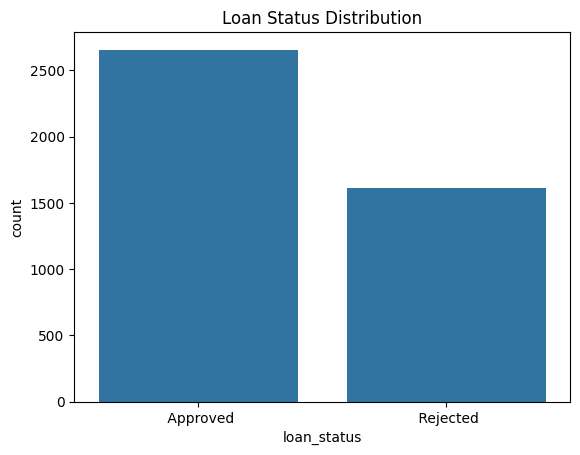

In [8]:
sns.countplot(x='loan_status', data=df)
plt.title("Loan Status Distribution")
plt.show()

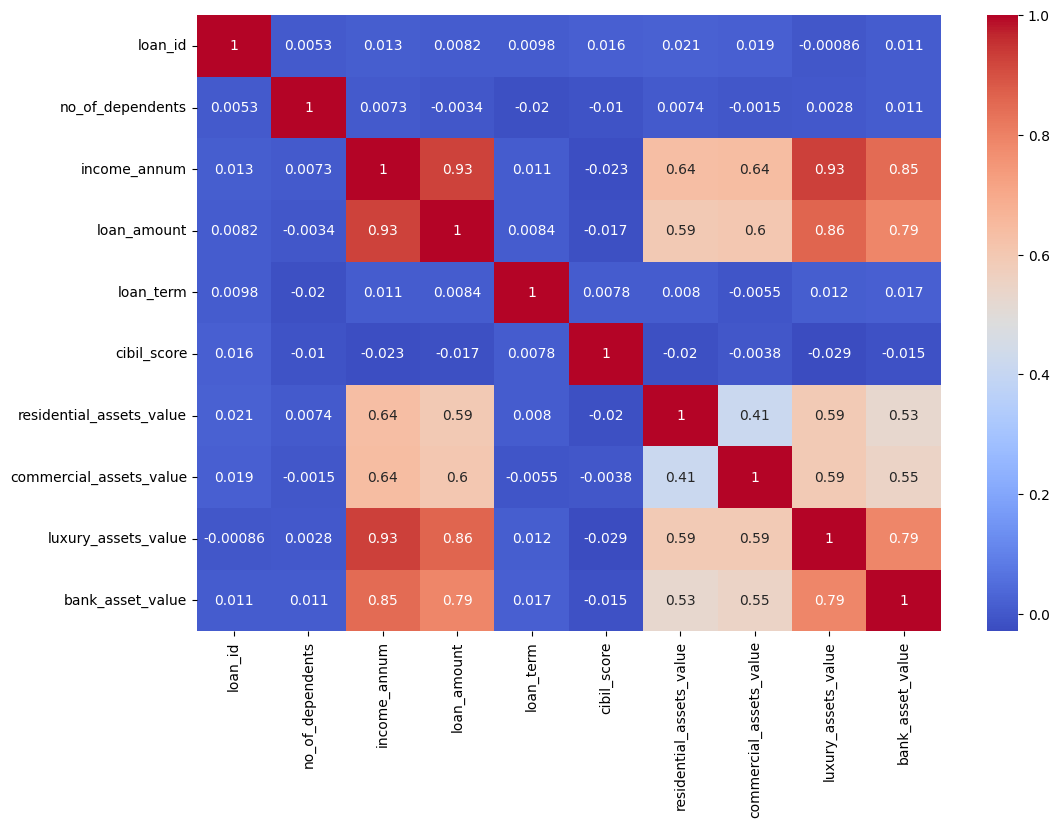

In [9]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64


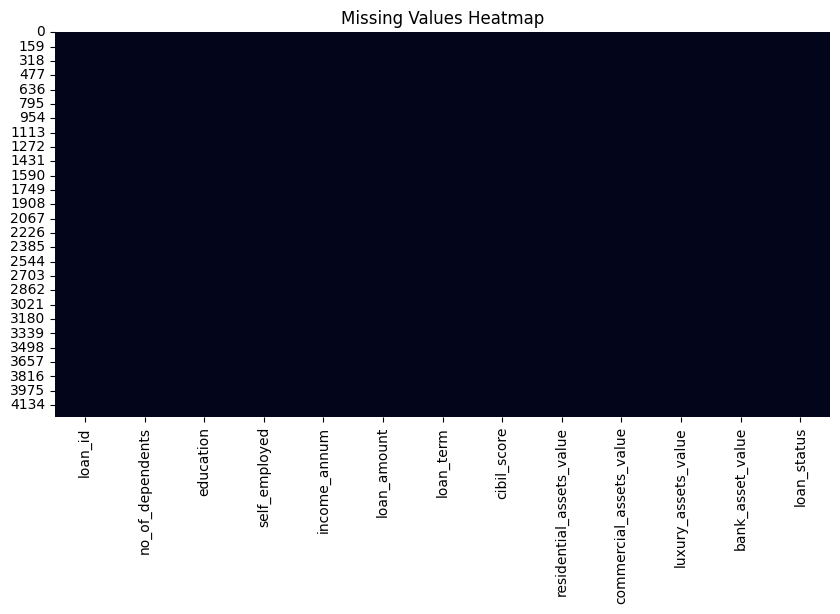

In [10]:
missing = df.isnull().sum()

print(missing)

plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

In [11]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


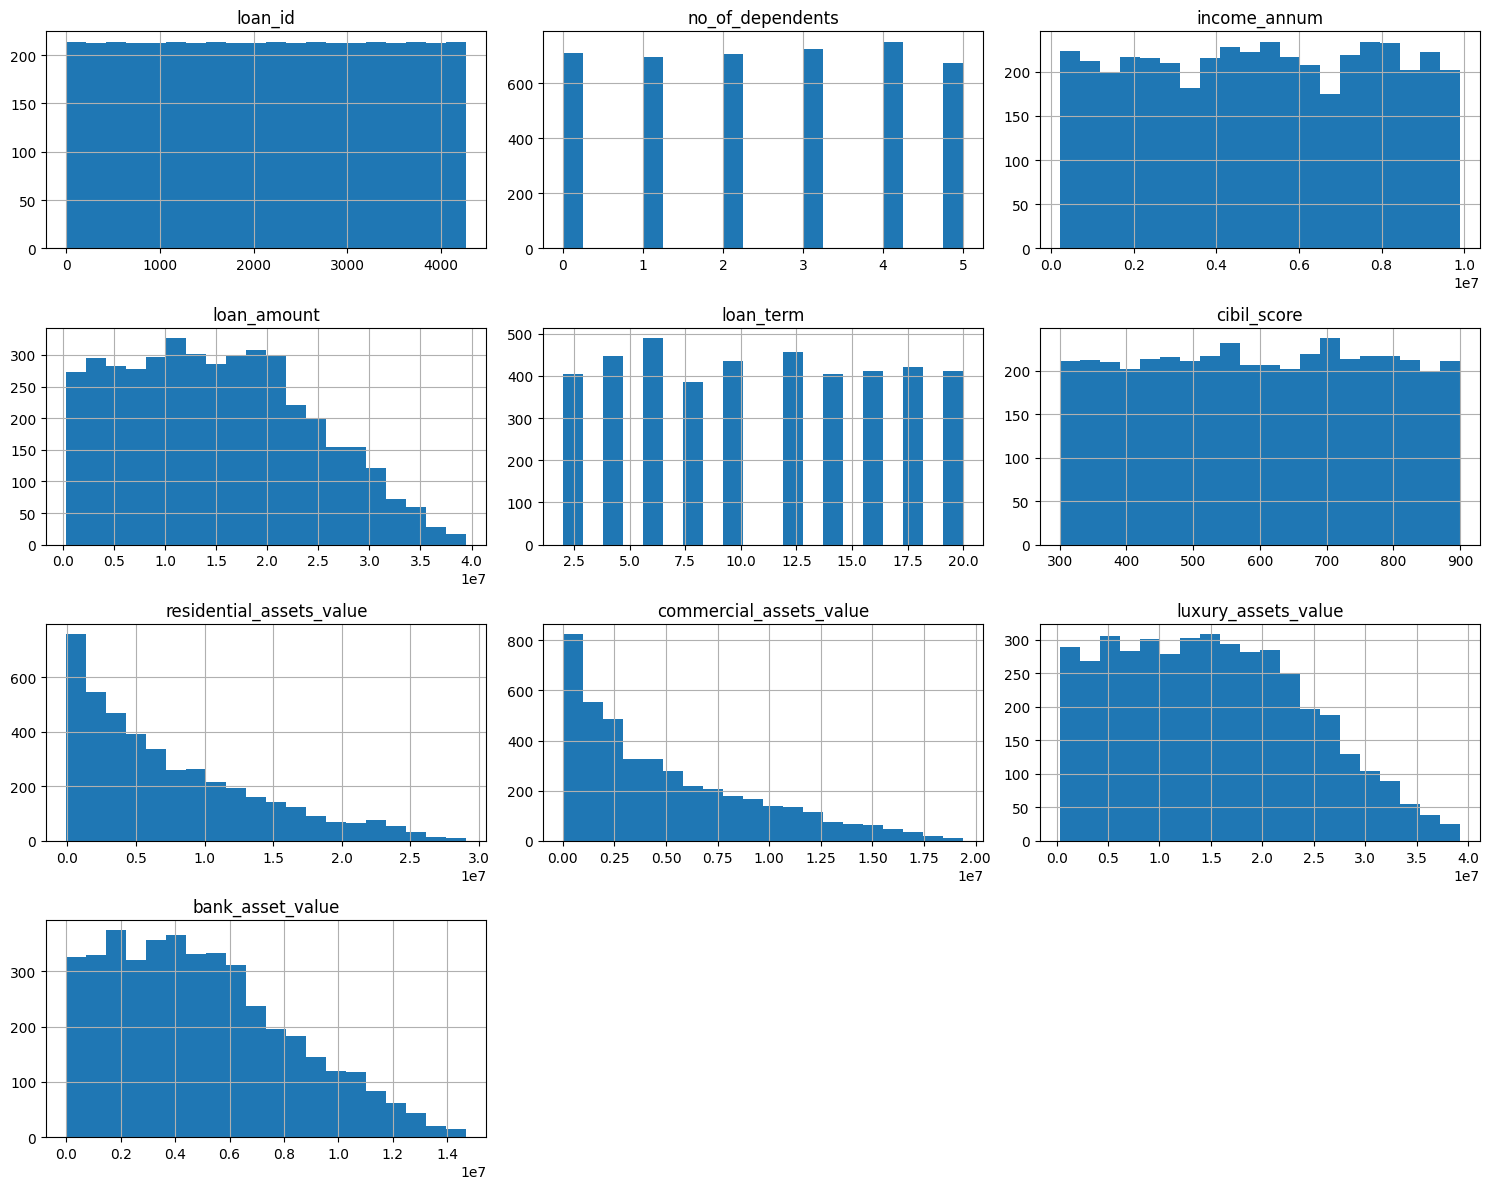

In [12]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

df[num_cols].hist(
    figsize=(15,12),
    bins=20
)

plt.tight_layout()
plt.show()

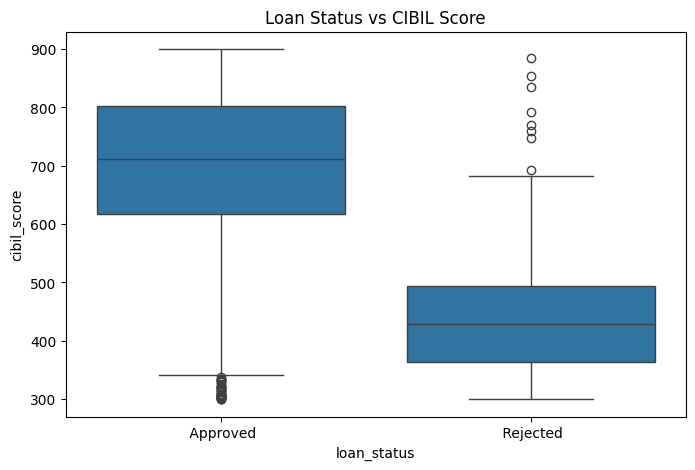

In [13]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='loan_status',
    y='cibil_score',
    data=df
)

plt.title("Loan Status vs CIBIL Score")
plt.show()

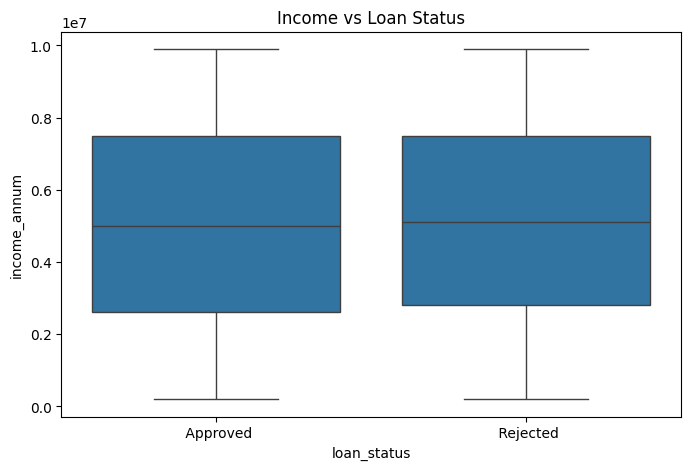

In [14]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='loan_status',
    y='income_annum',
    data=df
)

plt.title("Income vs Loan Status")
plt.show()

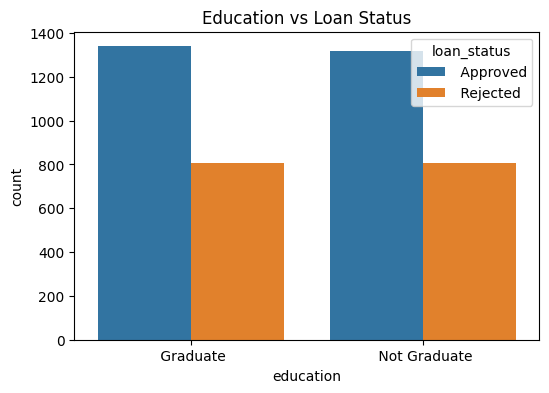

In [15]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='education',
    hue='loan_status',
    data=df
)

plt.title("Education vs Loan Status")
plt.show()

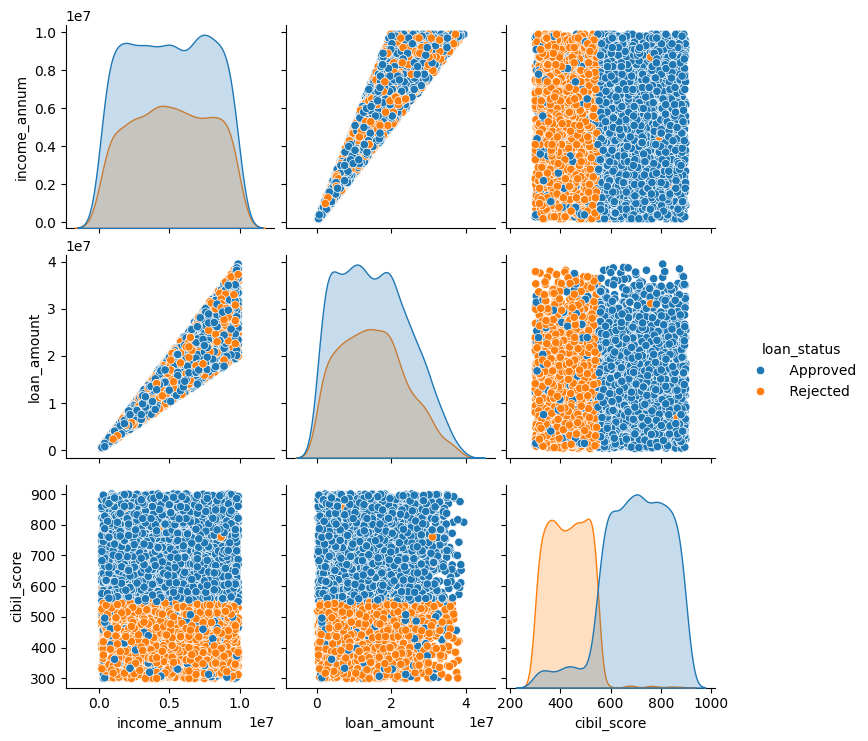

In [16]:
cols = [
    'income_annum',
    'loan_amount',
    'cibil_score',
    'loan_status'
]

sns.pairplot(
    df[cols],
    hue='loan_status'
)

plt.show()

In [17]:
approval_rate = (
    df['loan_status']
    .value_counts(normalize=True) * 100
)

print(approval_rate)

loan_status
Approved    62.215976
Rejected    37.784024
Name: proportion, dtype: float64


In [18]:
from sklearn.preprocessing import LabelEncoder

In [19]:
le = LabelEncoder()

df['education'] = le.fit_transform(df['education'])
df['self_employed'] = le.fit_transform(df['self_employed'])
df['loan_status'] = le.fit_transform(df['loan_status'])
df.head()



,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,0,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0
1,2,0,1,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1
2,3,3,0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,1
3,4,3,0,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,1
4,5,5,1,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1


In [20]:
X = df.drop(['loan_id','loan_status'], axis=1)

y = df['loan_status']

In [21]:
from sklearn.model_selection import train_test_split

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(3415, 11)
(854, 11)


In [23]:
from sklearn.preprocessing import StandardScaler

In [24]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(X_train.shape)
print(X_test.shape)

(3415, 11)
(854, 11)


In [25]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Model Trained Successfully")

Model Trained Successfully


In [26]:
from sklearn.metrics import accuracy_score

In [27]:
print("Accuracy:", accuracy_score(y_test, y_pred_lr))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.905152224824356

Classification Report

              precision    recall  f1-score   support

           0       0.92      0.93      0.92       536
           1       0.88      0.86      0.87       318

    accuracy                           0.91       854
   macro avg       0.90      0.90      0.90       854
weighted avg       0.90      0.91      0.90       854



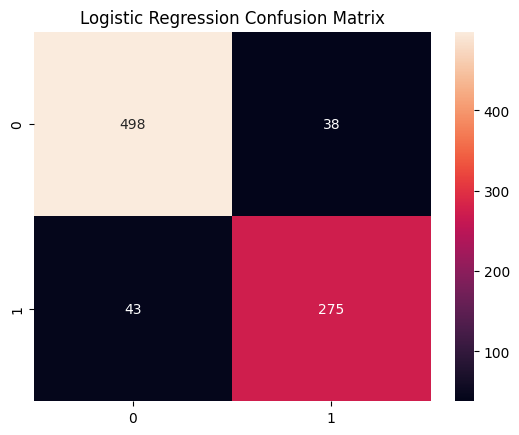

In [28]:
cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [29]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [30]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.977751756440281

Classification Report

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       536
           1       0.98      0.96      0.97       318

    accuracy                           0.98       854
   macro avg       0.98      0.97      0.98       854
weighted avg       0.98      0.98      0.98       854



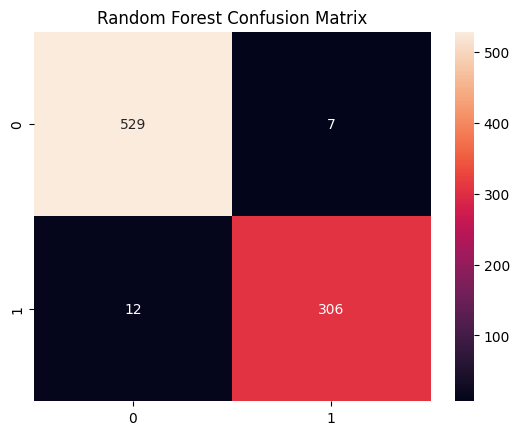

In [31]:
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Random Forest Confusion Matrix")
plt.show()

In [32]:
lr_acc = accuracy_score(y_test, y_pred_lr)
rf_acc = accuracy_score(y_test, y_pred_rf)

comparison = pd.DataFrame({
    "Model":["Logistic Regression","Random Forest"],
    "Accuracy":[lr_acc,rf_acc]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.905152
1,Random Forest,0.977752


In [33]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
6,cibil_score,0.814127
5,loan_term,0.063645
4,loan_amount,0.028502
3,income_annum,0.017692
7,residential_assets_value,0.017340
9,luxury_assets_value,0.017006
10,bank_asset_value,0.014932
8,commercial_assets_value,0.013939
0,no_of_dependents,0.008222
2,self_employed,0.002484


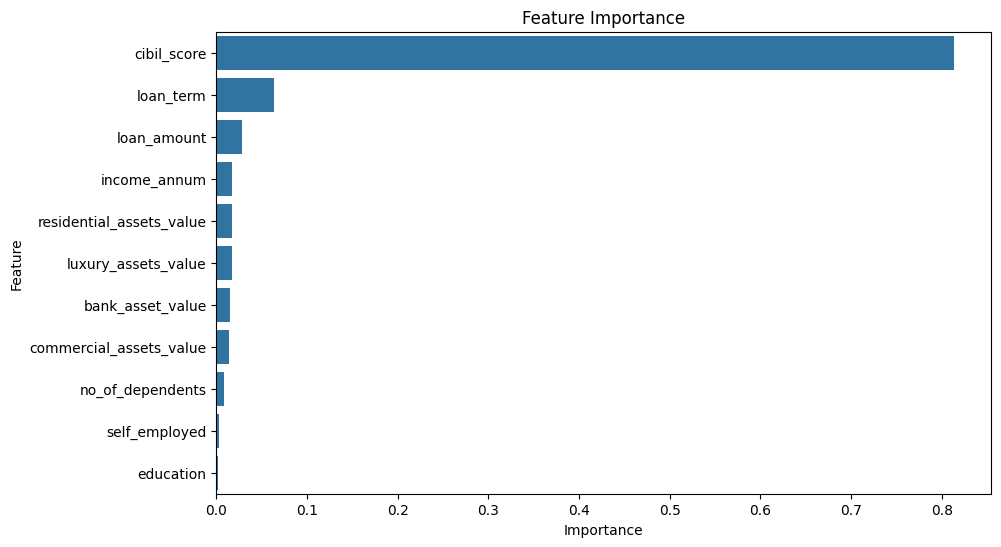

In [34]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title("Feature Importance")
plt.show()

In [35]:
import joblib

joblib.dump(rf, "loan_approval_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [36]:
model = joblib.load("loan_approval_model.pkl")
scaler = joblib.load("scaler.pkl")